In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import mean_absolute_percentage_error

Inlezen data

In [2]:
kijkcijfers = pd.read_csv('./data2/feat_eng/kijkcijfers_weerdata.csv')
# SE = sentence embedding
kijkcijfers_SE = pd.read_csv('./data2/feat_eng/kijkcijfers_weerdata_met_sentence_embedding.csv')

# Opsplitsen in train en test set

In [3]:
cutoff = pd.Timestamp('2023-01-01')

kijkcijfers['timestamp'] = pd.to_datetime(kijkcijfers['timestamp'])

train_set_temp = kijkcijfers[kijkcijfers['timestamp'] < cutoff]
test_set_temp = kijkcijfers[kijkcijfers['timestamp'] >= cutoff]

train_set = train_set_temp.select_dtypes(include=[np.number])
test_set = test_set_temp.select_dtypes(include=[np.number])

X_train = train_set.drop(columns=['viewers'])
y_train = train_set['viewers']

X_test = test_set.drop(columns=['viewers'])
y_test = test_set['viewers']

In [11]:
cutoff = pd.Timestamp('2023-01-01')

kijkcijfers_SE['timestamp'] = pd.to_datetime(kijkcijfers_SE['timestamp'])

train_set_temp_SE = kijkcijfers_SE[kijkcijfers_SE['timestamp'] < cutoff]
test_set_temp_SE = kijkcijfers_SE[kijkcijfers_SE['timestamp'] >= cutoff]

train_set_SE = train_set_temp_SE.select_dtypes(include=[np.number])
test_set_SE = test_set_temp_SE.select_dtypes(include=[np.number])

X_train_SE = train_set_SE.drop(columns=['viewers'])
y_train_SE = train_set_SE['viewers']

X_test_SE = test_set_SE.drop(columns=['viewers'])
y_test_SE = test_set_SE['viewers']

In [ ]:
cutoff = pd.Timestamp('2023-01-01')

kijkcijfers['timestamp'] = pd.to_datetime(kijkcijfers['timestamp'])

kijkcijfers.drop(columns=['program'], inplace=True)

train_set_timeseries = kijkcijfers[kijkcijfers['timestamp'] < cutoff]
test_set_timeseries = kijkcijfers[kijkcijfers['timestamp'] >= cutoff]

train_set_timeseries.set_index('timestamp', inplace=True)
test_set_timeseries.set_index('timestamp', inplace=True)

print(train_set_timeseries.info())

X_train_timeseries = train_set_timeseries.drop(columns=['viewers'])
y_train_timeseries = train_set_timeseries['viewers']

X_test_timeseries = test_set_timeseries.drop(columns=['viewers'])
y_test_timeseries = test_set_timeseries['viewers']

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 45087 entries, 2016-10-03 20:14:23 to 2022-12-31 15:33:46
Columns: 178 entries, year to program_target_enc
dtypes: float64(168), int64(10)
memory usage: 61.6 MB
None


,year,month,day,hour,duration_sec,viewers,temperature_2m,precipitation,rain,snowfall,...,wereld,wielrennen,wild,witse,wk,zake,zevende,zomer,zoo,program_target_enc
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-10-03 20:14:23,2016,10,3,20,1530.0,1268561,15.3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.060569e+06
2016-10-03 19:47:08,2016,10,3,19,1253.0,1111170,16.7,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.923806e+05
2016-10-03 19:00:05,2016,10,3,19,2683.0,1077321,16.7,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.923798e+05
2016-10-03 20:41:32,2016,10,3,20,2793.0,1063322,15.3,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.685588e+05
2016-10-03 18:32:01,2016,10,3,18,1611.0,754051,17.8,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.393389e+05


Hulpfuncties om modellen te testen

In [12]:
def test_model(model, X, y, n_splits=5, scoring='neg_mean_absolute_error'):
    # Pipeline die voor trainen standard scaling toepast
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Om in plaats van gewone folds, gebruik te maken van TimeSeriesSplit om trends in de tijd te behouden
    tscv = TimeSeriesSplit(n_splits=n_splits)
    
    # Voer cross-validatie uit
    scores = cross_val_score(pipeline, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    
    # Gemiddelde en standaarddeviatie van de scores
    mean_score = -np.mean(scores)
    std_score = np.std(scores)
    
    print(f"Mean MAE: {mean_score:.3f} (+/- {std_score:.3f})")
    return scores

def test_model_list(list, X, y, n_splits=5, scoring='neg_mean_absolute_error'):
    for model in list:
        print(f"Testing model: {model.__class__.__name__}")
        test_model(model, X, y, n_splits=n_splits, scoring=scoring)

# Baseline models testing

In [13]:
ridge_reg = Ridge()

In [14]:
scores = test_model(ridge_reg, X_train, y_train)
scores_SE = test_model(ridge_reg, X_train_SE, y_train_SE)

print(f'Scores: {scores}\nScores_SE: {scores_SE}')

Mean MAE: 92790.431 (+/- 9726.184)


KeyboardInterrupt: 

# Other models testing

In [ ]:
rf_reg = RandomForestRegressor()
gb_reg = GradientBoostingRegressor()
xgb_reg = XGBRegressor()

In [ ]:
print("Without sentence embedding")
test_model_list([rf_reg, gb_reg, xgb_reg], X_train, y_train)

print("\nWith sentence embedding")
test_model_list([rf_reg, gb_reg, xgb_reg], X_train_SE, y_train_SE)

Without sentence embedding
Testing model: RandomForestRegressor
Mean MAE: 62890.985 (+/- 4959.426)
Testing model: GradientBoostingRegressor
Mean MAE: 69094.292 (+/- 5034.250)
Testing model: XGBRegressor
Mean MAE: 63209.376 (+/- 6686.836)

With sentence embedding
Testing model: RandomForestRegressor
Mean MAE: 62737.096 (+/- 4780.647)
Testing model: GradientBoostingRegressor
Mean MAE: 69110.550 (+/- 5595.626)
Testing model: XGBRegressor
Mean MAE: 65609.922 (+/- 7339.826)


Aan de hand van deze resultaten zal ik verder een XGBRegressor model proberen finetunen op de data zonder sentence embedding, omdat RandomForestRegressor extreem veel langer duurt om te trainen

# Finetuning

In [15]:
from scipy.stats import uniform, randint

param_distributions = {
    'xgb__n_estimators': randint(100, 500),
    'xgb__learning_rate': uniform(0.01, 0.2),
    "xgb__min_child_weight": randint(1, 10),
    'xgb__max_depth': randint(3, 10),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4),
    'xgb__gamma': uniform(0, 0.3)
}

tscv = TimeSeriesSplit(n_splits=5)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(n_jobs=-1))
])

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_distributions,
    n_iter=500,  # Aantal combinaties om te testen
    scoring='neg_mean_absolute_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

In [16]:
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best score found: ", -random_search.best_score_)

tuned_model = random_search.best_estimator_

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters found:  {'xgb__colsample_bytree': np.float64(0.9669127652498348), 'xgb__gamma': np.float64(0.0905411267666526), 'xgb__learning_rate': np.float64(0.025959422249457166), 'xgb__max_depth': 9, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 326, 'xgb__subsample': np.float64(0.6557567765776106)}
Best score found:  60055.5375


In [17]:
# Voorspellingen maken met het getunede model
y_pred = tuned_model.predict(X_test)

# MAPE berekenen
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {mape:.4f}")

MAPE: 0.1882


Fitting 5 folds for each of 50 candidates, totalling 250 fits\
Best parameters found:  {\
    'xgb__colsample_bytree': np.float64(0.8493192507310232),\
    'xgb__gamma': np.float64(0.09926940745579475), \
    'xgb__learning_rate': np.float64(0.02271167005720473), \
    'xgb__max_depth': 9, \
    'xgb__min_child_weight': 8, \
    'xgb__n_estimators': 392, \
    'xgb__subsample': np.float64(0.8918424713352255)}\
Best score found:  60196.19921875\
\
MAPE: 0.1915

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best parameters found:  {\
'xgb__colsample_bytree': np.float64(0.9504682673682698), \
'xgb__gamma': np.float64(0.026635697855998952), \
'xgb__learning_rate': np.float64(0.03387485492450079), \
'xgb__max_depth': 8, \
'xgb__min_child_weight': 4, \
'xgb__n_estimators': 310, \
'xgb__subsample': np.float64(0.7803206763176206)}\
Best score found:  59925.29453125\
\
MAPE: 0.1913

Fitting 5 folds for each of 500 candidates, totalling 2500 fits\
Best parameters found:  {'xgb__colsample_bytree': np.float64(0.9669127652498348), 'xgb__gamma': np.float64(0.0905411267666526), 'xgb__learning_rate': np.float64(0.025959422249457166), 'xgb__max_depth': 9, 'xgb__min_child_weight': 5, 'xgb__n_estimators': 326, 'xgb__subsample': np.float64(0.6557567765776106)}
Best score found:  60055.5375\
\
MAPE: 0.1882

In [19]:
with open('./models2/tuned_xgb_model_randomsearch.pkl', 'wb') as f:
    pickle.dump(tuned_model, f)

Met optuna

In [7]:
import optuna

def objective(trial):
    # XGBoost parameters
    n_estimators = trial.suggest_int('n_estimators', 100, 1000)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    max_depth = trial.suggest_int('max_depth', 3, 15)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
    gamma = trial.suggest_float('gamma', 0.0, 0.5)
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(n_estimators=n_estimators,
                                learning_rate=learning_rate,
                                min_child_weight=min_child_weight,
                                max_depth=max_depth,
                                subsample=subsample,
                                colsample_bytree=colsample_bytree,
                                gamma=gamma, 
                                n_jobs=-1))
    ])
    
    tscv = TimeSeriesSplit(n_splits=5)

    score = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
    
    return score  # Hoe hoger, hoe beter

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=42))
study.optimize(objective, n_trials=250)

print("Beste parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

print("\nBeste score (neg. MAE):", study.best_value)

[I 2025-04-06 21:02:15,685] A new study created in memory with name: no-name-e957752f-85b7-4052-93e9-816168038646
[I 2025-04-06 21:02:28,134] Trial 0 finished with value: -71482.49609375 and parameters: {'n_estimators': 437, 'learning_rate': 0.2536999076681772, 'min_child_weight': 8, 'max_depth': 10, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.02904180608409973}. Best is trial 0 with value: -71482.49609375.
[I 2025-04-06 21:02:37,379] Trial 1 finished with value: -64508.08828125 and parameters: {'n_estimators': 880, 'learning_rate': 0.07725378389307355, 'min_child_weight': 8, 'max_depth': 3, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 0.10616955533913808}. Best is trial 1 with value: -64508.08828125.
[I 2025-04-06 21:02:46,676] Trial 2 finished with value: -60779.54140625 and parameters: {'n_estimators': 263, 'learning_rate': 0.018659959624904916, 'min_child_weight': 4, 'max_depth': 9, 'subsample': 0.71597250

Beste parameters:
  n_estimators: 715
  learning_rate: 0.012955509905129132
  min_child_weight: 9
  max_depth: 9
  subsample: 0.740293288663324
  colsample_bytree: 0.7962038923297587
  gamma: 0.4123404829625746

Beste score (neg. MAE): -60014.1140625


C:\Users\dylan\AppData\Local\Temp\ipykernel_43220\2008879538.py:3: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

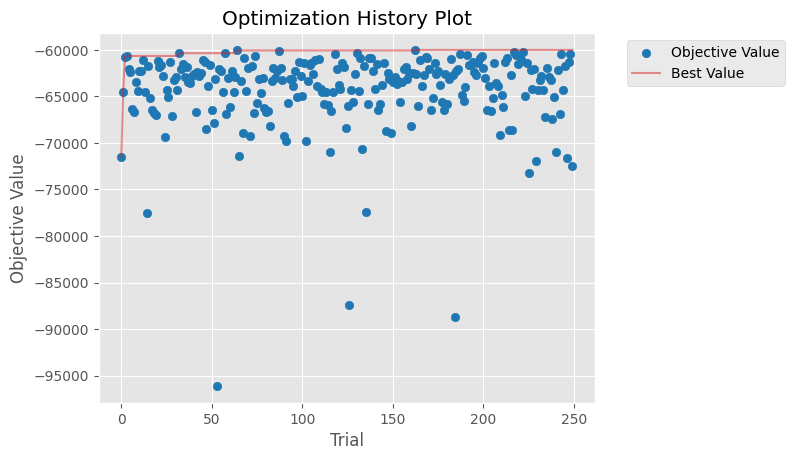

In [13]:
import matplotlib.pyplot as plt

optuna.visualization.matplotlib.plot_optimization_history(study)

C:\Users\dylan\AppData\Local\Temp\ipykernel_43220\361124950.py:1: ExperimentalWarning: plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study, params=["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "gamma"])


<Axes: title={'center': 'Parallel Coordinate Plot'}>

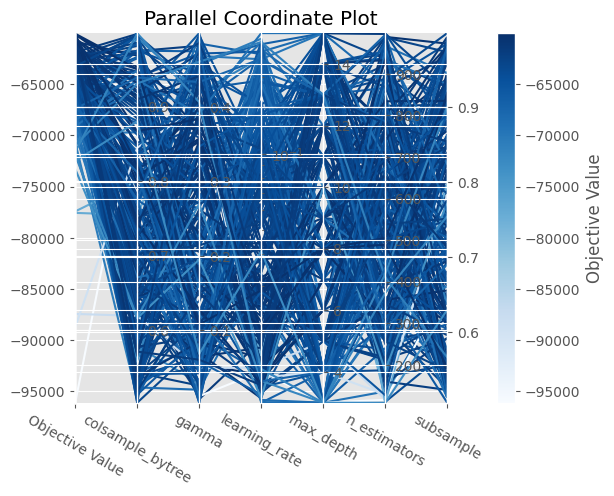

In [15]:
optuna.visualization.matplotlib.plot_parallel_coordinate(study, params=["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "gamma"])

C:\Users\dylan\AppData\Local\Temp\ipykernel_43220\2641587305.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study, params=["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "gamma", "min_child_weight"])


array([<Axes: xlabel='colsample_bytree', ylabel='Objective Value'>,
       <Axes: xlabel='gamma'>, <Axes: xlabel='learning_rate'>,
       <Axes: xlabel='max_depth'>, <Axes: xlabel='min_child_weight'>,
       <Axes: xlabel='n_estimators'>, <Axes: xlabel='subsample'>],
      dtype=object)

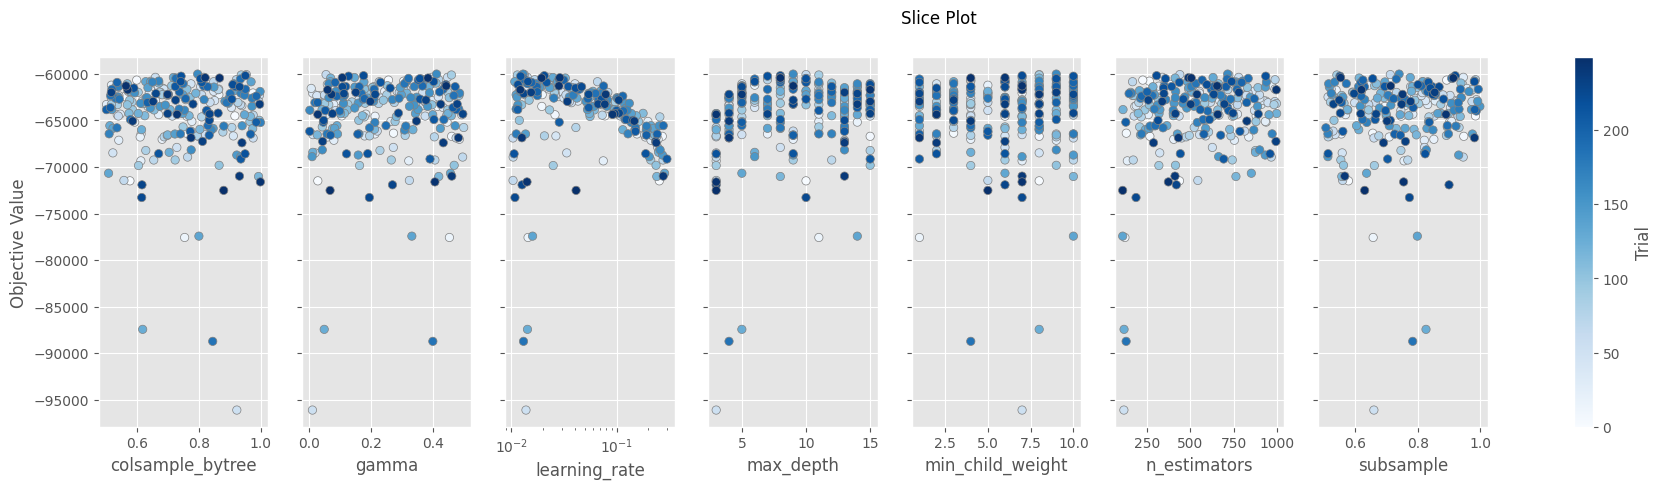

In [18]:
optuna.visualization.matplotlib.plot_slice(study, params=["n_estimators", "learning_rate", "max_depth", "subsample", "colsample_bytree", "gamma", "min_child_weight"])

C:\Users\dylan\AppData\Local\Temp\ipykernel_43220\1036994904.py:1: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

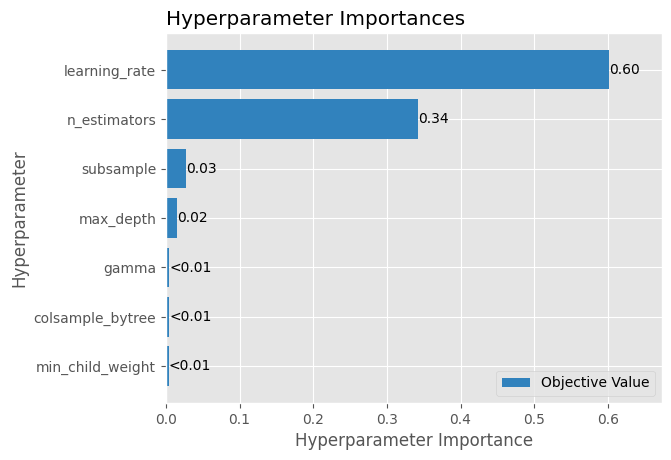

In [17]:
optuna.visualization.matplotlib.plot_param_importances(study)

In [22]:
import optuna

def objective(trial):
    # XGBoost parameters
    n_estimators = trial.suggest_int('n_estimators', 250, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.02, log=True)
    min_child_weight = 9
    max_depth = 8
    subsample = 0.9
    colsample_bytree = 0.5
    gamma = 0.1
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(n_estimators=n_estimators,
                                learning_rate=learning_rate,
                                min_child_weight=min_child_weight,
                                max_depth=max_depth,
                                subsample=subsample,
                                colsample_bytree=colsample_bytree,
                                gamma=gamma, 
                                n_jobs=-1))
    ])
    
    tscv = TimeSeriesSplit(n_splits=5)

    score = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='neg_mean_absolute_error', n_jobs=-1).mean()
    
    return score  # Hoe hoger, hoe beter

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=42))
study.optimize(objective, n_trials=50)

print("Beste parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

print("\nBeste score (neg. MAE):", study.best_value)

[I 2025-04-06 23:07:06,436] A new study created in memory with name: no-name-d5946929-9c78-46a3-990c-527f3b01c86d
[I 2025-04-06 23:07:18,825] Trial 0 finished with value: -61204.00078125 and parameters: {'n_estimators': 344, 'learning_rate': 0.019328294024559513}. Best is trial 0 with value: -61204.00078125.
[I 2025-04-06 23:07:34,782] Trial 1 finished with value: -61223.6265625 and parameters: {'n_estimators': 433, 'learning_rate': 0.015143078054173715}. Best is trial 0 with value: -61204.00078125.
[I 2025-04-06 23:07:44,391] Trial 2 finished with value: -65202.309375 and parameters: {'n_estimators': 289, 'learning_rate': 0.01114189418881991}. Best is trial 0 with value: -61204.00078125.
[I 2025-04-06 23:07:52,694] Trial 3 finished with value: -61930.46328125 and parameters: {'n_estimators': 264, 'learning_rate': 0.018228251054233664}. Best is trial 0 with value: -61204.00078125.
[I 2025-04-06 23:08:02,860] Trial 4 finished with value: -61246.840625 and parameters: {'n_estimators': 40

Beste parameters:
  n_estimators: 493
  learning_rate: 0.017113476012774725

Beste score (neg. MAE): -60977.1140625


C:\Users\dylan\AppData\Local\Temp\ipykernel_43220\3727359112.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study, params=["n_estimators", "learning_rate", "subsample", "colsample_bytree", "min_child_weight"])


array([<Axes: xlabel='colsample_bytree', ylabel='Objective Value'>,
       <Axes: xlabel='learning_rate'>, <Axes: xlabel='min_child_weight'>,
       <Axes: xlabel='n_estimators'>, <Axes: xlabel='subsample'>],
      dtype=object)

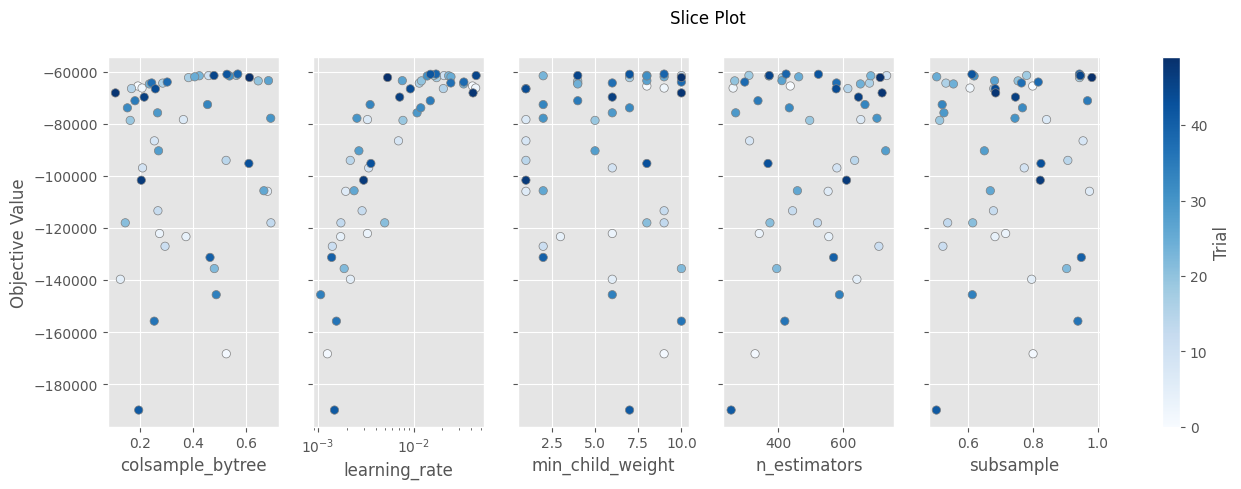

In [21]:
optuna.visualization.matplotlib.plot_slice(study, params=["n_estimators", "learning_rate", "subsample", "colsample_bytree", "min_child_weight"])

In [24]:
n_estimators = 715
learning_rate = 0.012955509905129132
min_child_weight = 9
max_depth = 9
subsample = 0.740293288663324
colsample_bytree = 0.7962038923297587
gamma = 0.4123404829625746

best_model = XGBRegressor(
    n_estimators=n_estimators,
    learning_rate=learning_rate,
    min_child_weight=min_child_weight,
    max_depth=max_depth,
    subsample=subsample,
    colsample_bytree=colsample_bytree,
    gamma=gamma,
    n_jobs=-1,
    random_state=42,
)
best_model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred = best_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE of the best model: {mape:.4f}")

MAPE of the best model: 0.1922
